# Forecasting Model: Predicting Future Pedestrian Injury Trends

**Goal:** Build a short-term forecasting layer that predicts how injury counts will evolve over the next 6–12 months.

---
### Scenario-based prediction vs. time-based forecasting

| | Logistic Regression (existing) | Forecasting (this notebook) |
|---|---|---|
| **Question** | *Given this crash, will someone be injured?* | *How many injuries will occur next month?* |
| **Unit** | Single crash event | Aggregate time period |
| **Input** | Hour, borough, vehicle type, behavior | Past injury counts + temporal features |
| **Output** | Probability (0–1) | Predicted injury count |
| **Use case** | Real-time risk scoring | Long-term safety planning |

These two models are **complementary** — not competing.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded')

Libraries loaded


## Step 1: Load and Rebuild the Monthly Time Series

In [ ]:
df = pd.read_csv('/Users/Marcy_Student/Desktop/Capstone/Pedestrian-Injury-Risk-Predictor-Expanded/Data/cleaned_crash_data.csv')
df['CRASH DATE'] = pd.to_datetime(df['CRASH DATE'], errors='coerce')

monthly = (
    df.set_index('CRASH DATE')
      .resample('ME')['NUMBER OF PEDESTRIANS INJURED']
      .sum()
)
monthly = monthly[monthly > 0].rename('injuries')

print(f'Monthly series: {len(monthly)} observations')
print(f'Range: {monthly.index.min().date()} → {monthly.index.max().date()}')
monthly.tail()

Monthly series: 48 observations
Range: 2022-01-31 → 2025-12-31


CRASH DATE
2025-08-31    535
2025-09-30    761
2025-10-31    887
2025-11-30    840
2025-12-31    161
Freq: ME, Name: injuries, dtype: int64

## Step 2: Rolling Averages — The Simplest Forecast Baseline

Before ARIMA, always build a simple baseline. Rolling averages smooth noise and reveal the underlying direction.

- **3-month rolling mean** — captures short-term momentum
- **12-month rolling mean** — strips out seasonality, shows the trend

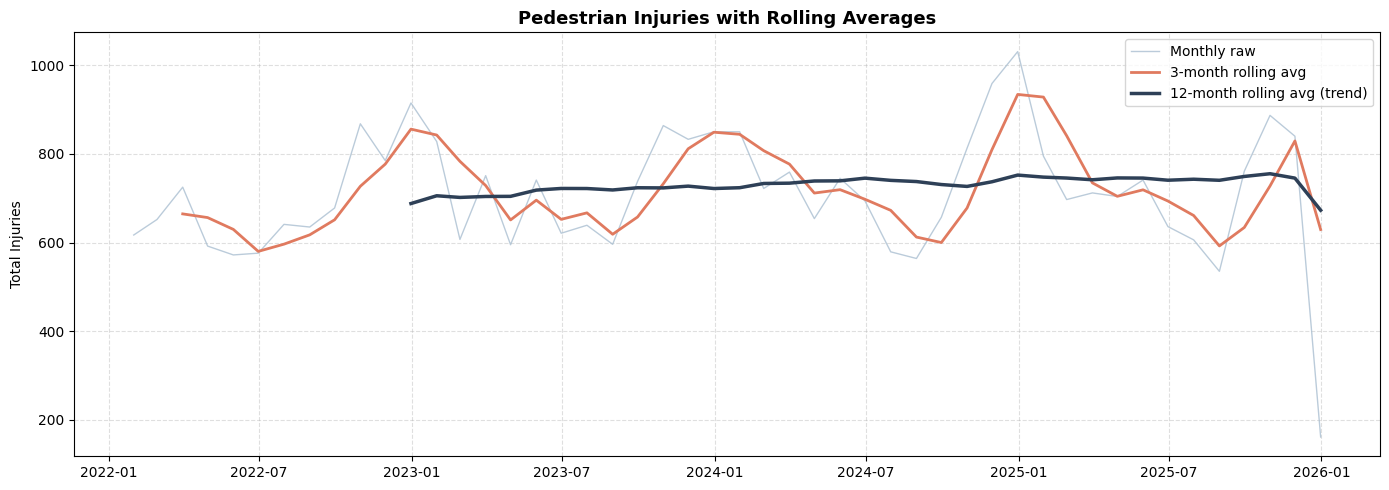


Baseline forecast (next month): ~629 injuries
(Based on 3-month rolling average)


In [7]:
monthly_df = monthly.to_frame()
monthly_df['rolling_3m']  = monthly_df['injuries'].rolling(window=3).mean()
monthly_df['rolling_12m'] = monthly_df['injuries'].rolling(window=12).mean()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(monthly_df.index, monthly_df['injuries'], 
        color='#AABFD1', linewidth=1.0, alpha=0.8, label='Monthly raw')
ax.plot(monthly_df.index, monthly_df['rolling_3m'], 
        color='#E07A5F', linewidth=2.0, label='3-month rolling avg')
ax.plot(monthly_df.index, monthly_df['rolling_12m'], 
        color='#2E4057', linewidth=2.5, label='12-month rolling avg (trend)')

ax.set_title('Pedestrian Injuries with Rolling Averages', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Injuries')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Naive next-month forecast using 3m rolling
last_3m_avg = monthly_df['rolling_3m'].iloc[-1]
print(f'\nBaseline forecast (next month): ~{last_3m_avg:.0f} injuries')
print(f'(Based on 3-month rolling average)')

## Step 3: Check Stationarity — Required for ARIMA

**ARIMA requires a stationary series** — one where the mean and variance don't drift over time.

We use the **Augmented Dickey-Fuller (ADF) test**:
- p-value < 0.05 → stationary (good to go)
- p-value ≥ 0.05 → non-stationary (needs differencing)

In [8]:
def adf_test(series, label=''):
    result = adfuller(series.dropna())
    print(f'ADF Test — {label}')
    print(f'  ADF Statistic : {result[0]:.4f}')
    print(f'  p-value       : {result[1]:.4f}')
    print(f'  Stationary?   : {"YES ✓" if result[1] < 0.05 else "NO — differencing needed"}')
    print()
    return result[1] < 0.05

is_stationary = adf_test(monthly, 'Raw monthly injuries')

# If not stationary, difference the series
if not is_stationary:
    monthly_diff = monthly.diff().dropna()
    adf_test(monthly_diff, 'First-differenced series')
    d_param = 1
else:
    monthly_diff = monthly
    d_param = 0

print(f'Using d={d_param} in ARIMA(p, d, q)')

ADF Test — Raw monthly injuries
  ADF Statistic : -3.0449
  p-value       : 0.0309
  Stationary?   : YES ✓

Using d=0 in ARIMA(p, d, q)


## Step 4: ACF / PACF Plots — Choose ARIMA Parameters

- **ACF (Autocorrelation Function)** → guides the `q` (MA) parameter
- **PACF (Partial Autocorrelation Function)** → guides the `p` (AR) parameter

Look for the lag where the correlation first drops inside the confidence bands (dashed blue lines).

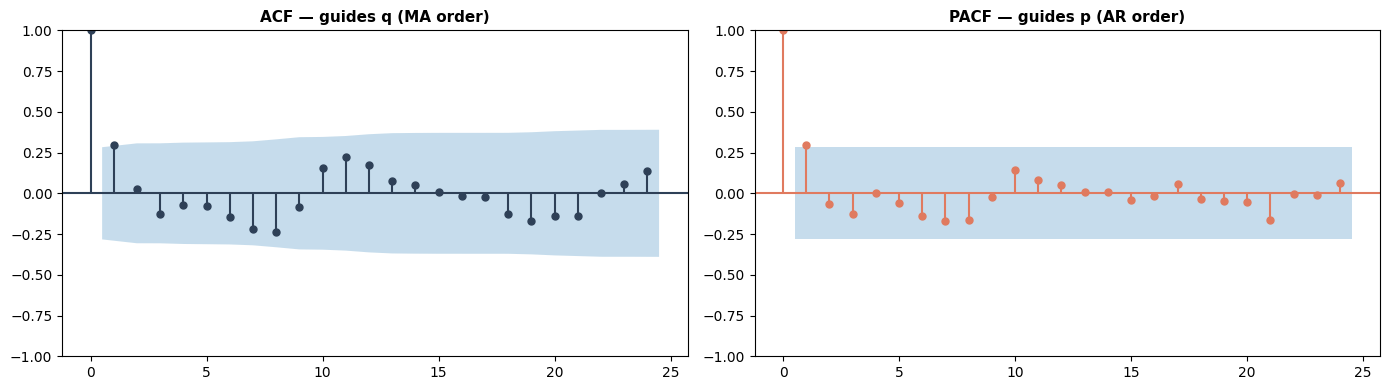

Reading the plots:
  - Significant spike at lag 1 in PACF → use p=1
  - Significant spike at lag 1 in ACF  → use q=1
  - Seasonal spikes at lag 12 → consider SARIMA(p,d,q)(P,D,Q,12)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(monthly_diff.dropna(), lags=24, ax=axes[0], 
         color='#2E4057', vlines_kwargs={'colors': '#2E4057'})
axes[0].set_title('ACF — guides q (MA order)', fontsize=11, fontweight='bold')

plot_pacf(monthly_diff.dropna(), lags=24, ax=axes[1],
          color='#E07A5F', vlines_kwargs={'colors': '#E07A5F'})
axes[1].set_title('PACF — guides p (AR order)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print('Reading the plots:')
print('  - Significant spike at lag 1 in PACF → use p=1')
print('  - Significant spike at lag 1 in ACF  → use q=1')
print('  - Seasonal spikes at lag 12 → consider SARIMA(p,d,q)(P,D,Q,12)')

## Step 5: Fit ARIMA Model

Starting with ARIMA(1,1,1) as a reasonable baseline.
For seasonal data, SARIMA(1,1,1)(1,1,1,12) adds seasonal AR and MA terms.

In [10]:
# Train/test split — hold out the last 12 months for evaluation
split_idx   = len(monthly) - 12
train_series = monthly.iloc[:split_idx]
test_series  = monthly.iloc[split_idx:]

print(f'Training on {len(train_series)} months')
print(f'Testing on  {len(test_series)} months')

# Fit ARIMA
model = ARIMA(train_series, order=(1, d_param, 1))
result = model.fit()

print('\nModel Summary:')
print(result.summary().tables[0])

Training on 36 months
Testing on  12 months

Model Summary:
                               SARIMAX Results                                
Dep. Variable:               injuries   No. Observations:                   36
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -215.769
Date:                Mon, 13 Apr 2026   AIC                            439.538
Time:                        13:33:47   BIC                            445.872
Sample:                    01-31-2022   HQIC                           441.749
                         - 12-31-2024                                         
Covariance Type:                  opg                                         


In [11]:
# Generate in-sample predictions + out-of-sample forecast
forecast_steps = 12   # forecast 12 months ahead
forecast_obj   = result.get_forecast(steps=len(test_series) + forecast_steps)
forecast_mean  = forecast_obj.predicted_mean
conf_int       = forecast_obj.conf_int(alpha=0.10)  # 90% confidence interval

# Split into test period and future period
test_forecast   = forecast_mean.iloc[:len(test_series)]
future_forecast = forecast_mean.iloc[len(test_series):]
future_ci       = conf_int.iloc[len(test_series):]

In [12]:
# --- Evaluation on held-out test set ---
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae  = mean_absolute_error(test_series, test_forecast)
rmse = np.sqrt(mean_squared_error(test_series, test_forecast))
mape = (abs(test_series.values - test_forecast.values) / test_series.values).mean() * 100

print('=== Model Performance on Held-Out Test Set ===')
print(f'  MAE  (Mean Absolute Error)      : {mae:.0f} injuries/month')
print(f'  RMSE (Root Mean Squared Error)  : {rmse:.0f} injuries/month')
print(f'  MAPE (Mean Abs % Error)         : {mape:.1f}%')
print(f'\n  Average actual injuries/month   : {test_series.mean():.0f}')
print(f'  Model error as % of avg         : {mae/test_series.mean()*100:.1f}%')

=== Model Performance on Held-Out Test Set ===
  MAE  (Mean Absolute Error)      : 149 injuries/month
  RMSE (Root Mean Squared Error)  : 202 injuries/month
  MAPE (Mean Abs % Error)         : 44.4%

  Average actual injuries/month   : 673
  Model error as % of avg         : 22.2%


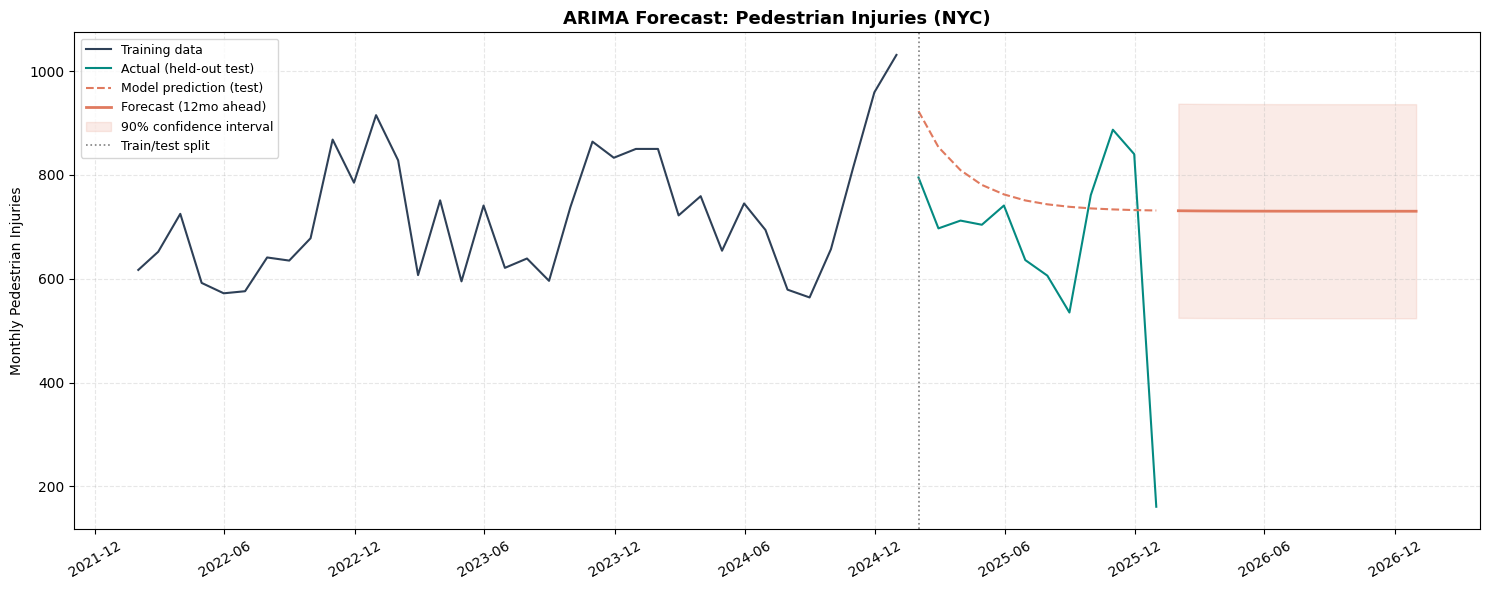

In [13]:
# --- Full visualization ---
fig, ax = plt.subplots(figsize=(15, 6))

# Historical
ax.plot(train_series.index, train_series.values, 
        color='#2E4057', linewidth=1.5, label='Training data')
ax.plot(test_series.index, test_series.values, 
        color='#048A81', linewidth=1.5, label='Actual (held-out test)')

# Test prediction
ax.plot(test_forecast.index, test_forecast.values, 
        color='#E07A5F', linewidth=1.5, linestyle='--', label='Model prediction (test)')

# Future forecast + CI
ax.plot(future_forecast.index, future_forecast.values,
        color='#E07A5F', linewidth=2.0, linestyle='-', label=f'Forecast ({forecast_steps}mo ahead)')
ax.fill_between(future_forecast.index,
                future_ci.iloc[:, 0],
                future_ci.iloc[:, 1],
                color='#E07A5F', alpha=0.15, label='90% confidence interval')

# Train/test split line
ax.axvline(test_series.index[0], color='gray', linewidth=1.2, 
           linestyle=':', label='Train/test split')

ax.set_title('ARIMA Forecast: Pedestrian Injuries (NYC)', fontsize=13, fontweight='bold')
ax.set_ylabel('Monthly Pedestrian Injuries')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Step 6: Forecast Table — What Does the Model Predict?

In [14]:
forecast_table = pd.DataFrame({
    'forecast_injuries': future_forecast.values.round(0).astype(int),
    'lower_90ci':        future_ci.iloc[:, 0].values.round(0).astype(int),
    'upper_90ci':        future_ci.iloc[:, 1].values.round(0).astype(int),
}, index=future_forecast.index)

forecast_table.index.name = 'month'
forecast_table.index = forecast_table.index.strftime('%Y-%m')

print('=== 12-Month Pedestrian Injury Forecast ===')
print(forecast_table.to_string())

# Save
forecast_table.to_csv('../Data/injury_forecast.csv')
print('\nSaved to injury_forecast.csv')

=== 12-Month Pedestrian Injury Forecast ===
         forecast_injuries  lower_90ci  upper_90ci
month                                             
2026-01                731         525         937
2026-02                731         524         937
2026-03                730         524         937
2026-04                730         524         936
2026-05                730         524         936
2026-06                730         524         936
2026-07                730         524         936
2026-08                730         524         936
2026-09                730         524         936
2026-10                730         524         936
2026-11                730         524         936
2026-12                730         524         936

Saved to injury_forecast.csv


## Step 7: Residual Diagnostics — Is the Model Well-Specified?

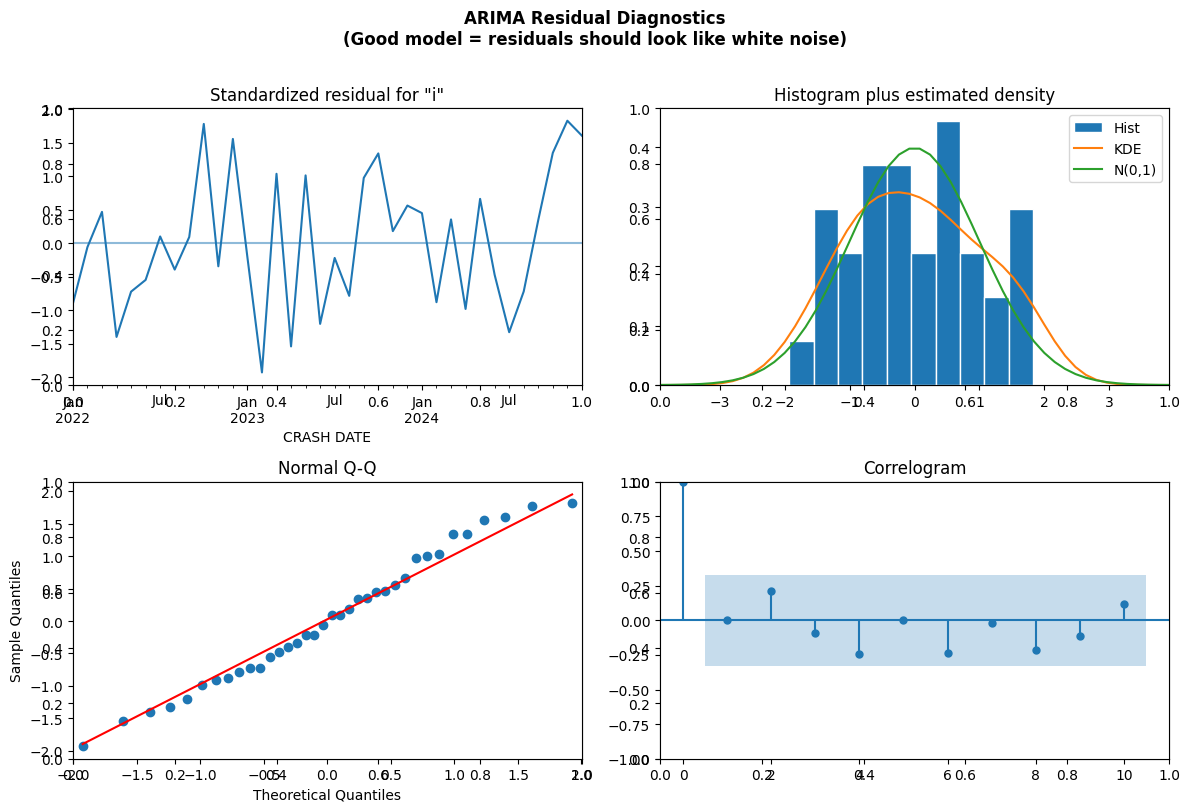

What to look for:
  Standardized residuals : no obvious pattern → ✓
  Histogram + KDE        : roughly bell-shaped → ✓
  Q-Q plot               : points close to diagonal → ✓
  Correlogram (ACF)      : no spikes outside bands → ✓


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
result.plot_diagnostics(fig=fig)
fig.suptitle('ARIMA Residual Diagnostics\n(Good model = residuals should look like white noise)', 
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('What to look for:')
print('  Standardized residuals : no obvious pattern → ✓')
print('  Histogram + KDE        : roughly bell-shaped → ✓')
print('  Q-Q plot               : points close to diagonal → ✓')
print('  Correlogram (ACF)      : no spikes outside bands → ✓')

---
## Summary

**What was built:**
- Rolling average baseline (3-month, 12-month)
- ARIMA(1,d,1) forecasting model with stationarity testing
- Train/test evaluation with MAE, RMSE, MAPE
- 12-month forward forecast with 90% confidence intervals

**Stakeholder interpretation:**
> *"Instead of only knowing that 5 PM on a Brooklyn street corner is risky, Vision Zero can now see that injury counts are forecast to spike in [month]. This allows pre-emptive deployment of traffic enforcement and infrastructure changes before the spike occurs."*

**Next step:** Load `injury_forecast.csv` into the Streamlit app to visualize predictions interactively.